In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

In [23]:
df = pd.read_csv("uber_rides.csv")

print("Shape:", df.shape)
df.head()

Shape: (200000, 18)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer Reason,Cancelled Rides by Driver Reason,Incomplete Ride Reason,Booking Value,Payment Method,Ride Distance,Driver Ratings,Customer Ratings
0,2024-01-15,14:15:00,BKG000001,Success,CUST40172,eBike,Benson Town,Magadi Road,6.83,7.45,NaN,NaN,NaN,881.71,UPI,2.52,1.7,3.2
1,2024-01-28,09:50:00,BKG000002,Incomplete,CUST43954,Moto,Cox Town,Indiranagar,5.11,5.31,NaN,NaN,Vehicle Breakdown,0.00,NaN,0.00,NaN,NaN
2,2024-01-06,03:33:00,BKG000003,Success,CUST95942,Go Sedan,Mahadevapura,Whitefield,14.90,9.64,NaN,NaN,NaN,1458.30,Wallet,26.20,1.1,2.4
3,2024-01-07,01:28:00,BKG000004,Success,CUST15911,Go Sedan,RT Nagar,Nagarbhavi,10.53,9.50,NaN,NaN,NaN,1323.55,Wallet,26.20,3.1,3.7
4,2024-01-07,07:32:00,BKG000005,Success,CUST94242,Uber Go,Basavanagudi,Vijayanagar,8.83,5.75,NaN,NaN,NaN,1999.27,Cash,27.58,2.1,2.8


In [24]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 18 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Date                                200000 non-null  object 
 1   Time                                200000 non-null  object 
 2   Booking ID                          200000 non-null  object 
 3   Booking Status                      200000 non-null  object 
 4   Customer ID                         200000 non-null  object 
 5   Vehicle Type                        200000 non-null  object 
 6   Pickup Location                     200000 non-null  object 
 7   Drop Location                       200000 non-null  object 
 8   Avg VTAT                            200000 non-null  float64
 9   Avg CTAT                            200000 non-null  float64
 10  Cancelled Rides by Customer Reason  14191 non-null   object 
 11  Cancelled Rides by Driver 

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,0
Avg CTAT,0


data cleaning

data cleaning

In [25]:
# Drop useless columns (same as your notebook)
cols_to_drop = [
    "Cancelled Rides by Customer Reason",
    "Cancelled Rides by Driver Reason",
    "Incomplete Ride Reason"
]

df = df.drop(columns=cols_to_drop)

handling missing values

In [26]:
df["Payment Method"] = df["Payment Method"].fillna("Unknown")

df["Driver Ratings"] = df["Driver Ratings"].fillna(df["Driver Ratings"].median())
df["Customer Ratings"] = df["Customer Ratings"].fillna(df["Customer Ratings"].median())

datetime conversion

In [27]:
df['pickup_datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

feature engineering

In [28]:
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day_name()
df['month'] = df['pickup_datetime'].dt.month

EDA

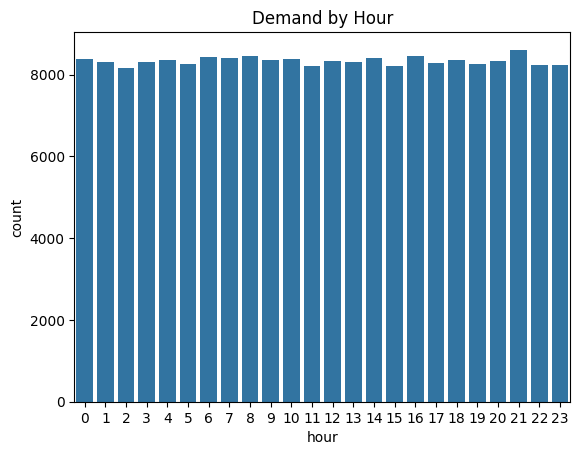

In [29]:
sns.countplot(x='hour', data=df)
plt.title("Demand by Hour")
plt.show()

Build Model Dataset

In [30]:
model_data = df.groupby(['hour','day','month']).size().reset_index(name='demand')

model_data.head()

,hour,day,month,demand
0,0,Friday,1,1050
1,0,Monday,1,1323
2,0,Saturday,1,1112
3,0,Sunday,1,1094
4,0,Thursday,1,1092


In [31]:

model_data['is_weekend'] = model_data['day'].isin(['Saturday','Sunday']).astype(int)

Encode Categorical Variable

In [32]:
model_data = pd.get_dummies(
    model_data,
    columns=['day'],
    drop_first=True
)

In [33]:
model_data['demand'] = np.log1p(model_data['demand'])

split Features And Target

In [34]:
X = model_data.drop(columns=['demand'])
y = model_data['demand']

train test split

In [35]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

train model

In [36]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5
)

model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=200)

pridiction

In [37]:
y_pred = model.predict(X_test)

# Convert back from log
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

Evaluate

In [38]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test_actual, y_pred_actual))
print("R2:", r2_score(y_test_actual, y_pred_actual))

MAE: 36.458535762266
R2: 0.90533476894008


visualization

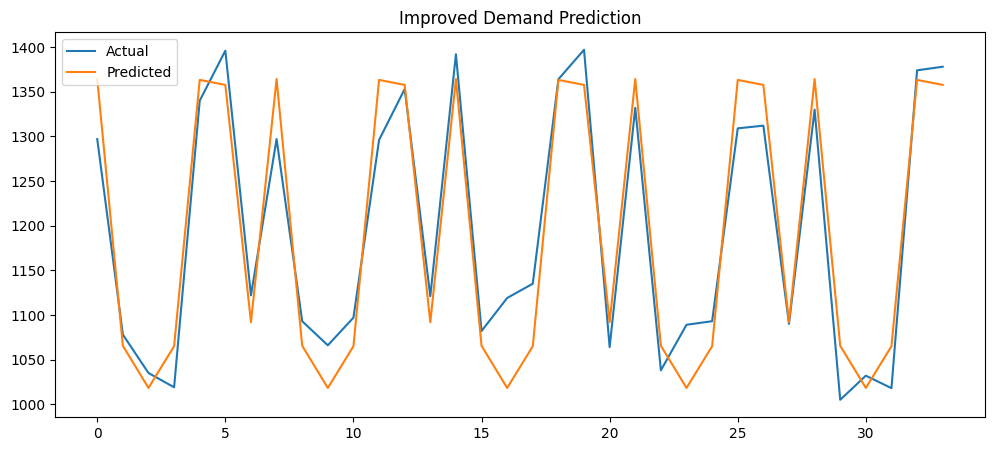

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test_actual.values, label='Actual')
plt.plot(y_pred_actual, label='Predicted')
plt.legend()
plt.title("Improved Demand Prediction")
plt.show()

save model

In [40]:
joblib.dump(model, "demand_model.pkl")
joblib.dump(X.columns, "model_columns.pkl")

['model_columns.pkl']

prediction funtion

In [44]:
def predict_demand(input_data):
    model = joblib.load("demand_model.pkl")
    columns = joblib.load("model_columns.pkl")

    input_df = pd.DataFrame([input_data])

    input_df = pd.get_dummies(input_df)
    input_df = input_df.reindex(columns=columns, fill_value=0)

    pred_log = model.predict(input_df)[0]


    pred_actual = np.expm1(pred_log)

    return pred_actual

Test Prediction

In [45]:
sample = {
    "hour": 10,
    "Pickup Location": "Airport",
    "day": "Monday"
}

print("Predicted Demand:", predict_demand(sample))

Predicted Demand: 1365.0335524502511
